Verify GPU Is **Enabled**

In [1]:
import torch

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


GPU available: True
GPU name: Tesla T4


**Install Required Libraries**

In [2]:
!pip install -q transformers datasets sentencepiece accelerate scikit-learn indic-nlp-library


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 14.0 MB/s eta 0:00:00


**Verify Installations**

In [3]:
import sklearn
import torch
import transformers
import datasets

print("sklearn:", sklearn.__version__)
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)


sklearn: 1.6.1
torch: 2.10.0+cu128
transformers: 5.0.0
datasets: 4.0.0


**Load using Pandas**

In [4]:
import pandas as pd

# Change filename if needed
df = pd.read_csv("train.csv")

# View first 5 rows
df.head()


,content,labels
0,தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...,Neutral
1,அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...,Substantiated
2,ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து......,Opinionated
3,"எடப்பாடியை கண்டுகொள்ளாத ""எடப்பாடி""🫢\n ---\nஆதர...",Positive
4,எங்களின் அரசியல் அடுத்த தலைமுறைக்குமானது \n#மக...,Opinionated


**Basic Sanity Checks**

In [5]:
df.shape


(4352, 2)

In [6]:
df.columns

Index(['content', 'labels'], dtype='object')

In [7]:

df.isnull().sum()

,0
content,0
labels,0


**Label Distribution Analysis**

In [8]:
df['labels'].value_counts()


,count
labels,
Opinionated,1361
Sarcastic,790
Neutral,637
Positive,575
Substantiated,412
Negative,406
None of the above,171


**Verify Text Quality**

In [9]:
df.sample(5)[['content', 'labels']]


,content,labels
271,அரசியல் அமாவாசை பழனிசாமி ! - முதலமைச்சர் MK St...,Sarcastic
2786,பாட்டு பாடி கலக்கிய சீமான்!\nசிவகங்கை வேட்பாளர...,Positive
71,புதிய அரசியல் மாற்றத்திற்காக மக்களின் ஆதரவு சீ...,Sarcastic
311,#டிடிஎஃப் வாசன் #சீமான் அண்ணனுக்கு வாக்கு சேகர...,Opinionated
3406,டிரக்ஸ் முன்னேற்ற கழகம்; திமுகவுக்கு புதிதாக ப...,Opinionated


**Label Encoding**

In [10]:
import pandas as pd

train_df = pd.read_csv("train.csv")
dev_df   = pd.read_csv("dev.csv")



In [11]:
label2id = {
    "Substantiated": 0,
    "Sarcastic": 1,
    "Opinionated": 2,
    "Positive": 3,
    "Negative": 4,
    "Neutral": 5,
    "None of the above": 6
}

id2label = {v: k for k, v in label2id.items()}

for df in [train_df, dev_df]:
    df['label_id'] = df['labels'].map(label2id)

train_df[['labels', 'label_id']].head(), dev_df[['labels', 'label_id']].head()




(          labels  label_id
 0        Neutral         5
 1  Substantiated         0
 2    Opinionated         2
 3       Positive         3
 4    Opinionated         2,
           labels  label_id
 0    Opinionated         2
 1  Substantiated         0
 2        Neutral         5
 3       Negative         4
 4  Substantiated         0)

**TEXT PREPROCESSING**
Common Preprocessing (Applied to Both)

In [12]:
import re
import unicodedata

#Unicode Normalization (Tamil-safe)
def normalize_unicode(text):
    return unicodedata.normalize("NFC", text)

#Remove URLs
def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)

#Remove Mentions (@username)
def remove_mentions(text):
    return re.sub(r"@\w+", "", text)
#Basic Cleanup Function
def basic_preprocess(text):
    text = normalize_unicode(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = text.strip()
    return text
train_df['clean_text'] = train_df['content'].astype(str).apply(basic_preprocess)
dev_df['clean_text']   = dev_df['content'].astype(str).apply(basic_preprocess)

train_df[['content', 'clean_text']].head(), dev_df[['content', 'clean_text']].head()




(                                             content  \
 0  தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...   
 1  அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...   
 2  ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து......   
 3  எடப்பாடியை கண்டுகொள்ளாத "எடப்பாடி"🫢\n ---\nஆதர...   
 4  எங்களின் அரசியல் அடுத்த தலைமுறைக்குமானது \n#மக...   
 
                                           clean_text  
 0  தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...  
 1  அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...  
 2  ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து......  
 3  எடப்பாடியை கண்டுகொள்ளாத "எடப்பாடி"🫢\n ---\nஆதர...  
 4  எங்களின் அரசியல் அடுத்த தலைமுறைக்குமானது \n#மக...  ,
                                              content  \
 0  ஒற்றே அறை...\n\nபாஜக குளோஸ்!\n\n#மக்களின்_சின்...   
 1  வாய்ப்பில்லை சார் வாய்ப்பில்லை\n#சீமானின்_சின்...   
 2  ஒரே போடு இரண்டாக பிளக்கும் | வரலாற்றில் ஒருவன்...   
 3  இப்படியெல்லாம் எடிட் பண்ணிதான் ஓட்டு வாங்கணும்...   
 4  #Mike_VoiceOfPeople \n#NTK_Sym

**Baseline Preprocessing (TF-IDF + SVM)**

In [13]:
#Remove Emojis & Special Symbols
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.sub(r"", text)
#Remove Extra Punctuation & Numbers
def remove_special_chars(text):
    return re.sub(r"[^0-9A-Za-z\u0B80-\u0BFF\s]", "", text)
#Lowercasing (Safe for Tamil)
def lowercase(text):
    return text.lower()
#Final Baseline Pipeline
def preprocess_for_tfidf(text):
    text = basic_preprocess(text)
    text = remove_emojis(text)
    text = remove_special_chars(text)
    text = lowercase(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df['tfidf_text'] = train_df['content'].astype(str).apply(preprocess_for_tfidf)
dev_df['tfidf_text']   = dev_df['content'].astype(str).apply(preprocess_for_tfidf)

train_df[['content', 'tfidf_text']].head(), dev_df[['content', 'tfidf_text']].head()


(                                             content  \
 0  தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...   
 1  அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...   
 2  ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து......   
 3  எடப்பாடியை கண்டுகொள்ளாத "எடப்பாடி"🫢\n ---\nஆதர...   
 4  எங்களின் அரசியல் அடுத்த தலைமுறைக்குமானது \n#மக...   
 
                                           tfidf_text  
 0  தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...  
 1  அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...  
 2  ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து இன...  
 3  எடப்பாடியை கண்டுகொள்ளாத எடப்பாடி ஆதரிப்பீர் உத...  
 4  எங்களின் அரசியல் அடுத்த தலைமுறைக்குமானது மக்கள...  ,
                                              content  \
 0  ஒற்றே அறை...\n\nபாஜக குளோஸ்!\n\n#மக்களின்_சின்...   
 1  வாய்ப்பில்லை சார் வாய்ப்பில்லை\n#சீமானின்_சின்...   
 2  ஒரே போடு இரண்டாக பிளக்கும் | வரலாற்றில் ஒருவன்...   
 3  இப்படியெல்லாம் எடிட் பண்ணிதான் ஓட்டு வாங்கணும்...   
 4  #Mike_VoiceOfPeople \n#NTK_Sym

**Transformer Preprocessing (XLM-RoBERTa)**

In [14]:
#Minimal Cleaning Only
def preprocess_for_transformer(text):
    text = basic_preprocess(text)
    return text

train_df['xlmr_text'] = train_df['content'].astype(str).apply(preprocess_for_transformer)
dev_df['xlmr_text']   = dev_df['content'].astype(str).apply(preprocess_for_transformer)

train_df[['content', 'xlmr_text']].head(), dev_df[['content', 'xlmr_text']].head()




(                                             content  \
 0  தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...   
 1  அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...   
 2  ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து......   
 3  எடப்பாடியை கண்டுகொள்ளாத "எடப்பாடி"🫢\n ---\nஆதர...   
 4  எங்களின் அரசியல் அடுத்த தலைமுறைக்குமானது \n#மக...   
 
                                            xlmr_text  
 0  தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...  
 1  அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...  
 2  ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து......  
 3  எடப்பாடியை கண்டுகொள்ளாத "எடப்பாடி"🫢\n ---\nஆதர...  
 4  எங்களின் அரசியல் அடுத்த தலைமுறைக்குமானது \n#மக...  ,
                                              content  \
 0  ஒற்றே அறை...\n\nபாஜக குளோஸ்!\n\n#மக்களின்_சின்...   
 1  வாய்ப்பில்லை சார் வாய்ப்பில்லை\n#சீமானின்_சின்...   
 2  ஒரே போடு இரண்டாக பிளக்கும் | வரலாற்றில் ஒருவன்...   
 3  இப்படியெல்லாம் எடிட் பண்ணிதான் ஓட்டு வாங்கணும்...   
 4  #Mike_VoiceOfPeople \n#NTK_Sym

In [15]:
#Verify Preprocessing Differences (Reviewer-friendly)
train_df.sample(5)[['content', 'tfidf_text', 'xlmr_text']]



,content,tfidf_text,xlmr_text
446,தேர்தல் ஆணையத்தை அவமதித்தாரா சீமான்?#seeman #n...,தேர்தல் ஆணையத்தை அவமதித்தாரா சீமான்seeman naam...,தேர்தல் ஆணையத்தை அவமதித்தாரா சீமான்?#seeman #n...
1325,"GST, NEET தேர்வை கொண்டு வந்தது யார்? \n\n#seem...",gst neet தேர்வை கொண்டு வந்தது யார் seeman ntk ...,"GST, NEET தேர்வை கொண்டு வந்தது யார்? \n\n#seem..."
803,#BREAKING | ஒரே ஒரு கூட்டம்தான் மொத்தமும் காலி...,breaking ஒரே ஒரு கூட்டம்தான் மொத்தமும் காலி மு...,#BREAKING | ஒரே ஒரு கூட்டம்தான் மொத்தமும் காலி...
1675,திமுக ஓட்டுக்கு பணம் கொடுத்தால் ‘கஞ்சா விற்ற ப...,திமுக ஓட்டுக்கு பணம் கொடுத்தால் கஞ்சா விற்ற பண...,திமுக ஓட்டுக்கு பணம் கொடுத்தால் ‘கஞ்சா விற்ற ப...
1051,குருநாதருக்கே விபூதி அடித்த\n#அறிவாலயம்...🔥🤣\n...,குருநாதருக்கே விபூதி அடித்த அறிவாலயம் dmkfails...,குருநாதருக்கே விபூதி அடித்த\n#அறிவாலயம்...🔥🤣\n...


In [16]:
#Store Processed Data (Optional but Clean)
train_df[['tfidf_text', 'xlmr_text', 'label_id']].to_csv(
    "processed_train.csv",
    index=False
)

dev_df[['tfidf_text', 'xlmr_text', 'label_id']].to_csv(
    "processed_dev.csv",
    index=False
)

**BASELINE MODEL — TF-IDF + SVM**

In [17]:
#Prepare Train / Validation
X_train = train_df['tfidf_text']
y_train = train_df['label_id']

X_val = dev_df['tfidf_text']
y_val = dev_df['label_id']




#Create TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)



In [18]:
#Train the Model
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42
)

svm.fit(X_train_tfidf, y_train)
#Validate the Model

from sklearn.metrics import classification_report

y_val_pred = svm.predict(X_val_tfidf)

print(classification_report(
    y_val,
    y_val_pred,
    target_names=[id2label[i] for i in range(7)],
    digits=4
))




                   precision    recall  f1-score   support

    Substantiated     0.2353    0.2308    0.2330        52
        Sarcastic     0.3670    0.3478    0.3571       115
      Opinionated     0.3789    0.3987    0.3885       153
         Positive     0.2105    0.2319    0.2207        69
         Negative     0.1875    0.2353    0.2087        51
          Neutral     0.1846    0.1429    0.1611        84
None of the above     0.5556    0.5000    0.5263        20

         accuracy                         0.2996       544
        macro avg     0.3028    0.2982    0.2994       544
     weighted avg     0.2998    0.2996    0.2988       544



In [19]:
import pandas as pd

test_df = pd.read_csv("test.csv")
test_df.head()

,content
0,இஸ்லாமிய சகோதரர்களுடன் ரமலான் கொண்டாடிய அதிமுக...
1,\nஓபிஎஸ் - எடப்பாடி போட்டா போட்டி! திடீரென பணி...
2,இன்றைய பரப்புரை:\n\nநாம் தமிழர் கட்சி தலைமை ஒர...
3,"🇰🇬🎙️ இன்னும் 05 ஏ நாளில், வெல்வோம் தமிழராய் - ..."
4,டாஸ்மாக்ல மட்டும்தான் கருணாநிதி அவர்களின் பெய...


In [20]:
# 1. Preprocess test text
test_df['tfidf_text'] = test_df['content'].astype(str).apply(preprocess_for_tfidf)

# 2. Transform using trained TF-IDF vectorizer
X_test = test_df['tfidf_text']
X_test_tfidf = tfidf.transform(X_test)

# 3. Predict label IDs
test_preds = svm.predict(X_test_tfidf)

# 4. Convert IDs → label names
test_df['predicted_label'] = [id2label[i] for i in test_preds]

# 5. Save submission file with content + prediction
test_df[['content', 'predicted_label']].to_csv("baseline_submission.csv", index=False)

print("✅ Saved: baseline_submission.csv")



✅ Saved: baseline_submission.csv


<Figure size 800x600 with 0 Axes>

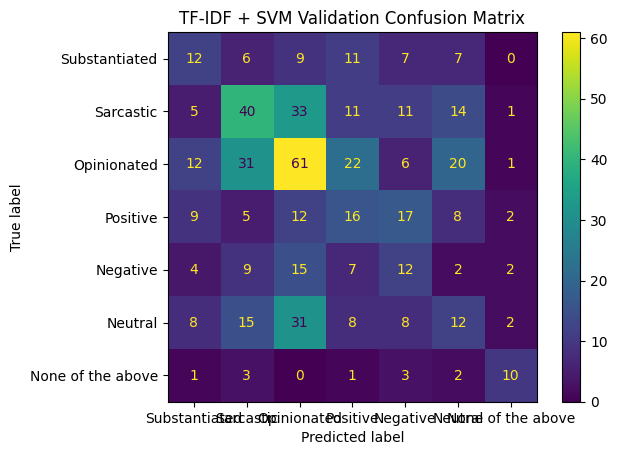

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[id2label[i] for i in range(7)]
)

plt.figure(figsize=(8, 6))
disp.plot(values_format='d')
plt.title("TF-IDF + SVM Validation Confusion Matrix")
plt.show()



**TRANSFORMER MODEL — XLM-RoBERTa**

In [22]:

# 1. Imports

import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)


# 2. Load Data

train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("dev.csv")
test_df  = pd.read_csv("test.csv")


# 3. Text Preprocessing

def preprocess_xlmr(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["xlmr_text"] = train_df["content"].apply(preprocess_xlmr)
val_df["xlmr_text"]   = val_df["content"].apply(preprocess_xlmr)
test_df["xlmr_text"]  = test_df["content"].apply(preprocess_xlmr)


# 4. Label Encoding

label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df["labels"])
val_labels   = label_encoder.transform(val_df["labels"])

id2label = dict(enumerate(label_encoder.classes_))
label2id = {v: k for k, v in id2label.items()}
num_labels = len(id2label)


# 5. Tokenizer

MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


# 6. Dataset Classes

class XLMRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        item = {k: v.squeeze() for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


class XLMRTestDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {k: v.squeeze() for k, v in encoding.items()}


# 7. Datasets

train_dataset = XLMRDataset(
    train_df["xlmr_text"].tolist(),
    train_labels,
    tokenizer
)

val_dataset = XLMRDataset(
    val_df["xlmr_text"].tolist(),
    val_labels,
    tokenizer
)


# 8. Class Weights (CRITICAL)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# 9. Model

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# 10. Custom Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


# 11. Metrics

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }


# 12. Training Arguments

training_args = TrainingArguments(
    output_dir="./xlmr_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=6,
    warmup_ratio=0.1,
    weight_decay=0.01,

    logging_steps=50,
    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none"
)

# 13. Trainer

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# 14. Train

trainer.train()


# 15. Evaluate

eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)


# 16. Predict on Test Set

test_dataset = XLMRTestDataset(
    test_df["xlmr_text"].tolist(),
    tokenizer
)

test_preds = trainer.predict(test_dataset)
test_label_ids = np.argmax(test_preds.predictions, axis=1)

test_df["predicted_label"] = [
    id2label[i] for i in test_label_ids
]


# 17. Save Submission

test_df[["content", "predicted_label"]].to_csv(
    "xlmr_submission.csv",
    index=False
)

print("✅ Saved submission: xlmr_submission.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Evaluation Results: {'eval_loss': 1.647888422012329, 'eval_accuracy': 0.35294117647058826, 'eval_macro_f1': 0.3523044460956029, 'eval_weighted_f1': 0.33522049476430077, 'eval_runtime': 4.3154, 'eval_samples_per_second': 126.06, 'eval_steps_per_second': 7.879, 'epoch': 6.0}
✅ Saved submission: xlmr_submission.csv


In [23]:
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)

Evaluation Results: {'eval_loss': 1.647888422012329, 'eval_accuracy': 0.35294117647058826, 'eval_macro_f1': 0.3523044460956029, 'eval_weighted_f1': 0.33522049476430077, 'eval_runtime': 4.4789, 'eval_samples_per_second': 121.459, 'eval_steps_per_second': 7.591, 'epoch': 6.0}


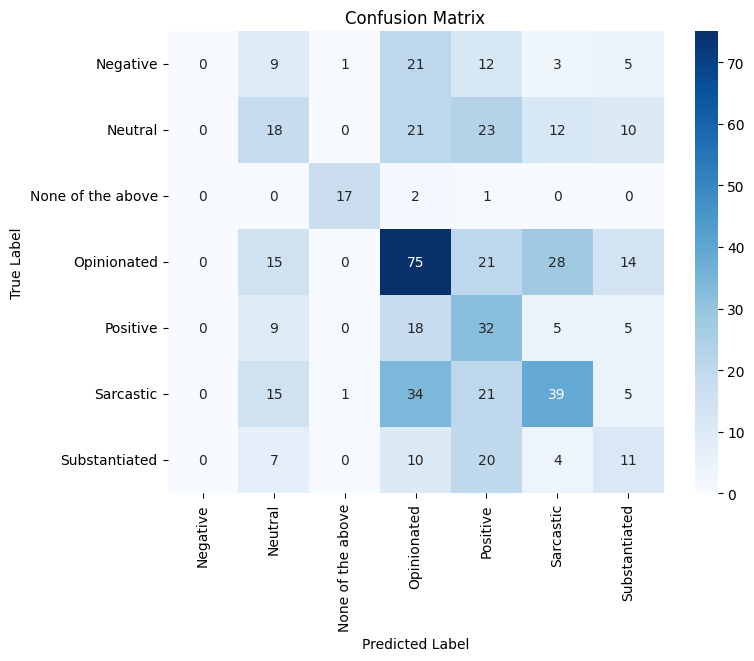

In [30]:
#confusion matrix heatmap
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(id2label.values()),
    yticklabels=list(id2label.values())
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

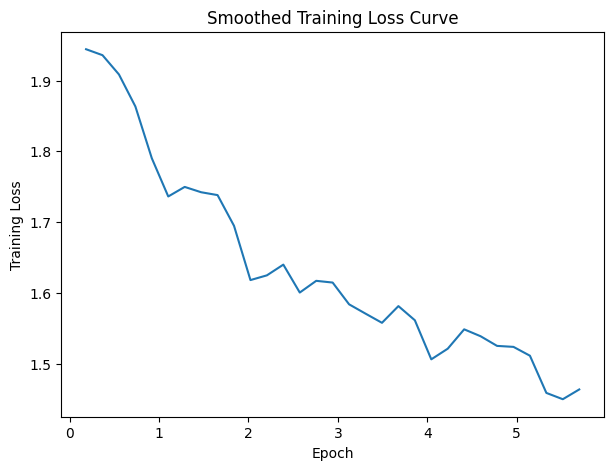

In [26]:
#Smoothed Training Loss Curve
import numpy as np

logs = trainer.state.log_history

train_loss = []
epochs = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
        epochs.append(log["epoch"])

# Smooth curve
window = 2
smoothed = np.convolve(train_loss, np.ones(window)/window, mode='valid')

plt.figure(figsize=(7,5))
plt.plot(epochs[:len(smoothed)], smoothed)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Smoothed Training Loss Curve")
plt.show()

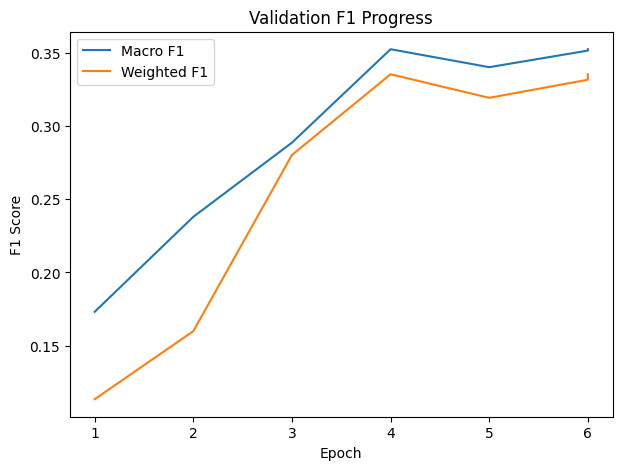

In [27]:
#Validation F1 Progress Graph
eval_macro = []
eval_weighted = []
epochs = []

for log in logs:
    if "eval_macro_f1" in log:
        eval_macro.append(log["eval_macro_f1"])
        eval_weighted.append(log["eval_weighted_f1"])
        epochs.append(log["epoch"])

plt.figure(figsize=(7,5))
plt.plot(epochs, eval_macro, label="Macro F1")
plt.plot(epochs, eval_weighted, label="Weighted F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 Progress")
plt.legend()
plt.show()